In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..')) # Pour aller chercher chez les parents 

from src.generation_profil import generer_profil_approbation, generer_profil_ordres, generer_profil_ordres_bruit, generer_profil_approbation_bruit 
from src.polarisation import calcul_mesure_pola_approbation, calcul_mesure_pola_ordres

Question 6. En utilisant les méthodes des questions 1,2, et 5 tracer l’évolution de la mésure φ2(p) en faisant varier “le niveau” de polarisation des instances à partir des arguments choisis aux questions 1 et 2.

In [3]:
n=50 #nbr de votants
m=10 #nbr de candidats
val_p=np.linspace(0,1,21) #21 valeurs de p de 0 à 1 (on fait varier p)
phi2_approbation=[]
phi2_ordres=[]
for p in val_p: #on génère les profils et on calcule la polarisation pour chaque p
    profil_approbation=generer_profil_approbation(n,m,p)
    profil_ordres=generer_profil_ordres(n,m,p)
    phi2_approbation.append(calcul_mesure_pola_approbation(profil_approbation))
    phi2_ordres.append(calcul_mesure_pola_ordres(profil_ordres)) 

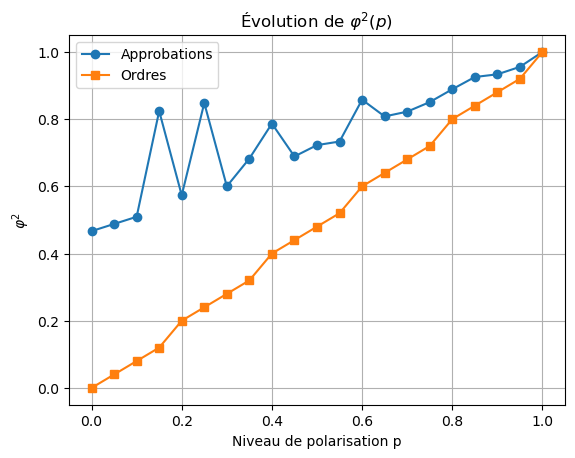

In [17]:
plt.plot(val_p, phi2_approbation, marker='o', label='Approbations')
plt.plot(val_p, phi2_ordres, marker='s', label='Ordres')

plt.title(r"Évolution de $\varphi^2(p)$ ")
plt.xlabel("Niveau de polarisation p")
plt.ylabel(r"$\varphi^2$")
plt.grid(True)
plt.legend()
plt.show()

Puisque nos profils de vote sont générés de manière aléatoire avec random, tracer la courbe à partir d'une seule élection donne une courbe non lisse. Pour obtenir un meilleur résultat, nous allons faire 20 éléctions pour chaque p et calculer leur moyenne. Cela permet d'annuler les variations dues au hasard et d'obtenir une courbe qui représente au mieux l'évolution de phi^2.

In [5]:
#Avec moyenne sur 20 simulations

nb_simu=20 
phi2_approbation_new=[]
phi2_ordres_new=[]
for p in val_p:
    somme_app=0
    somme_ord=0
    #on fait 20 élections pour le même p
    for _ in range(nb_simu):
        #on génère les profils
        profil_approbation=generer_profil_approbation(n,m,p)
        profil_ordres=generer_profil_ordres(n,m,p)
        #on calcule la polarisation et on l'ajoute à nos sommes
        somme_app+=calcul_mesure_pola_approbation(profil_approbation)
        somme_ord+=calcul_mesure_pola_ordres(profil_ordres)
    #on calcule les moyenne
    phi2_approbation_new.append(somme_app / nb_simu)
    phi2_ordres_new.append(somme_ord / nb_simu)


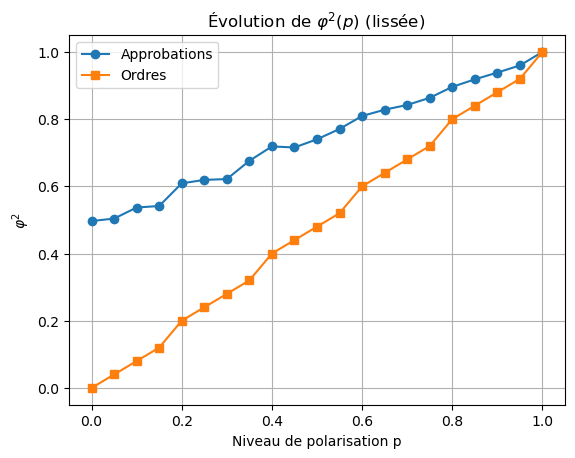

In [20]:
plt.plot(val_p, phi2_approbation_new, marker='o', label='Approbations')
plt.plot(val_p, phi2_ordres_new, marker='s', label='Ordres')

plt.title(r"Évolution de $\varphi^2(p)$ (lissée) ")
plt.xlabel("Niveau de polarisation p")
plt.ylabel(r"$\varphi^2$")
plt.grid(True)
plt.legend()
plt.show()

VERSION AVEC BRUIT (pour profil + réaliste)

In [6]:
n=50
m=10
val_p=np.linspace(0, 1, 21)
nb_simu=20

phi2_approbation_bruit=[]
phi2_ordres_bruit=[]

for p in val_p:
    somme_app=0
    somme_ord=0
    for _ in range(nb_simu):
        profil_approbation_bruit=generer_profil_approbation_bruit(n, m, p, bruit=0.1)
        profil_ordres_bruit=generer_profil_ordres_bruit(n, m, p, nb_swaps=2)
        somme_app+=calcul_mesure_pola_approbation(profil_approbation_bruit)
        somme_ord+=calcul_mesure_pola_ordres(profil_ordres_bruit)
    phi2_approbation_bruit.append(somme_app / nb_simu)
    phi2_ordres_bruit.append(somme_ord / nb_simu)

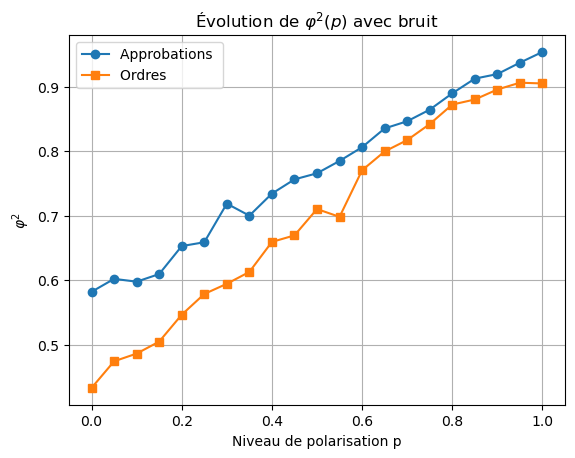

In [8]:
plt.plot(val_p, phi2_approbation_bruit, marker='o', label='Approbations ')
plt.plot(val_p, phi2_ordres_bruit, marker='s', label='Ordres ')

plt.title(r"Évolution de $\varphi^2(p)$ avec bruit")
plt.xlabel("Niveau de polarisation p")
plt.ylabel(r"$\varphi^2$")
plt.grid(True)
plt.legend()
plt.show()